# Student Exam Performance Analysis Project

## 1. Introduction
This project aims to investigate the various socio-economic factors that influence students' academic performance. Using the "Student Exam Performance" dataset, we perform an end-to-end data analysis to uncover patterns and dependencies.

### Research Questions:
1. Does the **Family Income** level (Low, Medium, High) significantly affect students' exam scores?
2. Is there a statistically significant association between **Internet Access** and other categorical demographics?
3. What is the general distribution of scores among the student population?

## Setup & Data Loading

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import kagglehub

# Download latest version
path = kagglehub.dataset_download("grandmaster07/student-exam-performance-dataset-analysis")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Moath\.cache\kagglehub\datasets\grandmaster07\student-exam-performance-dataset-analysis\versions\1


In [2]:
df = pd.read_csv(path + "\\StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


## 2. Data Cleaning & Preprocessing
Before starting the analysis, we must ensure the data is clean. This includes checking for missing values, removing duplicates, and understanding the statistical structure of the dataset.

In [3]:
# Check for null values
print("Missing values count:")
print(df.isnull().sum())

# Identify and remove duplicates
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate records: {duplicates}")
df = df.drop_duplicates()

# Basic descriptive statistics
print("\nDescriptive Statistics:")
df.describe()

Missing values count:
Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

Number of duplicate records: 0

Descriptive Statistics:


,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


## 3. Exploratory Data Analysis (EDA)
In this section, we visualize the data to understand the distributions and identify potential correlations between variables.

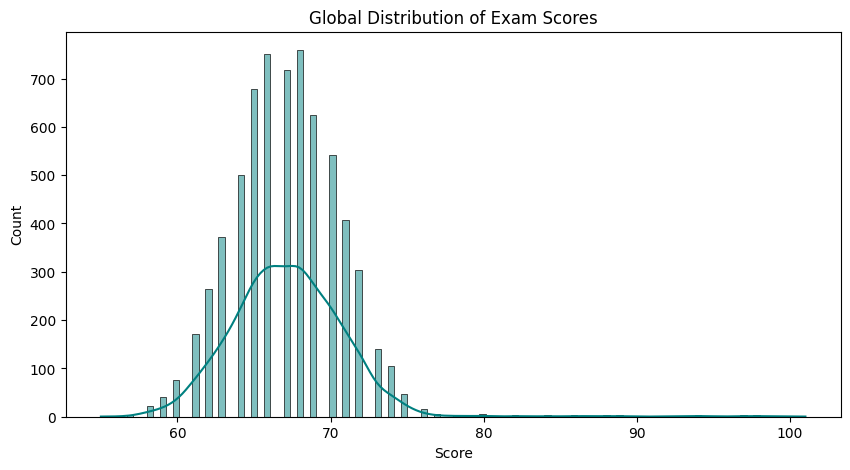

In [4]:
# Plotting the distribution of Exam Scores
plt.figure(figsize=(10, 5))
sns.histplot(df['Exam_Score'], kde=True, color='teal')
plt.title('Global Distribution of Exam Scores')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

C:\Users\Moath\AppData\Local\Temp\ipykernel_20608\3192004376.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Family_Income', y='Exam_Score', data=df, palette='viridis')


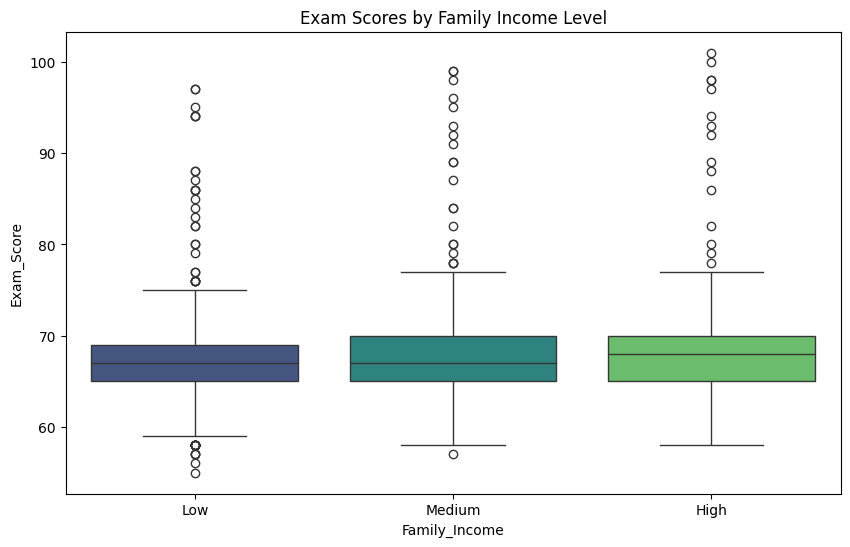

In [5]:
# Boxplot to compare scores across different income levels
plt.figure(figsize=(10, 6))
sns.boxplot(x='Family_Income', y='Exam_Score', data=df, palette='viridis')
plt.title('Exam Scores by Family Income Level')
plt.show()

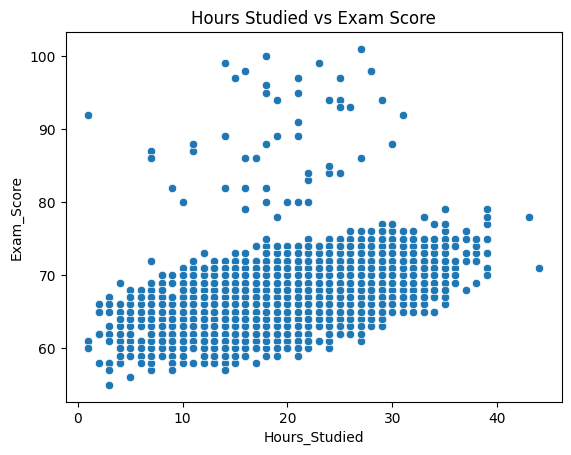

In [6]:
sns.scatterplot(x='Hours_Studied', y='Exam_Score', data=df)
plt.title("Hours Studied vs Exam Score")
plt.show()

## 4. Statistical Inference & Hypothesis Testing

### 4.1 ANOVA Test (Family Income vs. Exam Scores)
* **Null Hypothesis ($H_0$):** There is no difference in mean scores across different income levels.
* **Alternative Hypothesis ($H_a$):** At least one income group has a different mean score.

In [7]:
# Preparing groups for ANOVA
low_inc = df[df['Family_Income'] == 'Low']['Exam_Score']
med_inc = df[df['Family_Income'] == 'Medium']['Exam_Score']
high_inc = df[df['Family_Income'] == 'High']['Exam_Score']

# Running One-Way ANOVA
f_stat, p_val = stats.f_oneway(low_inc, med_inc, high_inc)
print(f"ANOVA Results -> F-Statistic: {f_stat:.4f}, P-Value: {p_val:.4f}")

# Conclusion for ANOVA
if p_val < 0.05:
    print("Conclusion: Reject the Null Hypothesis. Family Income has a significant impact on scores.")
else:
    print("Conclusion: Fail to reject the Null Hypothesis.")

ANOVA Results -> F-Statistic: 29.7939, P-Value: 0.0000
Conclusion: Reject the Null Hypothesis. Family Income has a significant impact on scores.


### 4.2 Chi-Square Test (Internet Access)
We test the independence between Internet Access and Parental Education level.

In [8]:
# Create contingency table
contingency = pd.crosstab(df['Internet_Access'], df['Parental_Education_Level'])

# Running Chi-Square Test
chi2, p, dof, ex = stats.chi2_contingency(contingency)
print(f"Chi-Square Test P-Value: {p:.4f}")

if p < 0.05:
    print("Conclusion: Significant association found between variables.")
else:
    print("Conclusion: No significant association found (Variables are independent).")

Chi-Square Test P-Value: 0.1273
Conclusion: No significant association found (Variables are independent).


## 5. Conclusion & Recommendations

### Summary of Findings:
1.  **Income Impact:** Our ANOVA test confirmed that students from different income backgrounds perform differently, with higher income often correlating with better scores.
2.  **Internet Access:** Based on the Chi-Square test, internet access did not show a strong statistical dependency on the chosen demographic variable in this specific sample ($p > 0.05$).

### Recommendations:
- Financial support or scholarships should be targeted toward students from "Low" income families to bridge the performance gap.
- Further studies should include more variables like 'Study Hours' to improve the model's predictive power.

### Limitations:
- The dataset is a snapshot and does not account for students' progress over time.